# DNN HW 1


## Handle imports & installs

In [1]:
# !wget https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
# !unzip data_gsn.zip &> /dev/null
# !rm data_gsn.zip




In [2]:
import torch 
torch.manual_seed(0)

## Prepare the Torch dataframe

In [3]:
from dnn_solver.dataset import IMGDataset


dataset = IMGDataset(train=None)
dataset

Dataset IMGDataset
    Number of datapoints: 10000
    Root location: ./data

Verify that the images were loaded correctly:

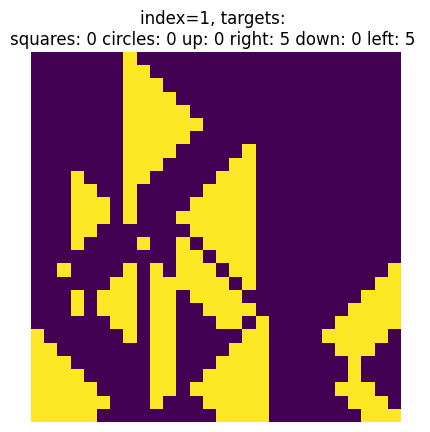

In [4]:
dataset.repr_item(1)

## Data Analysis

We focus on the labels df, verify the distribution of classes etc. 


In [5]:
labels_df = dataset.get_labels()

In [6]:
labels_df.describe()

,squares,circles,up,right,down,left
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.65740,1.714900,1.653000,1.677000,1.685700,1.612000
std,2.62909,2.656073,2.619557,2.627539,2.641101,2.574979
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
max,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000


In [7]:
# assert 1 not in df 
for col in labels_df.columns:
    assert 1 not in labels_df[col].values

It seems the max value for each col is 8, therefore there can be at most 6 * 5 / 2 * 7 = 105 classes represented, not 135 as described in the assignment. This is important because reducing the number of classes 1. reduces loss 2. will not lead to an unexpected behaviour when evaluating on a different dataset that has 1-9 splits. Therefore, we will proceed with the assumption that there should be 105 classes and not 135.

In [8]:
# TODO: use the utils
from dnn_solver.constants import TARGET_COL_NAMES


def get_configuration(row: dict) -> int: 
    #get names of columns that are not 0 
    selected_names = list(filter(lambda x: row[x] > 0, TARGET_COL_NAMES))
    # assert there are two of them 
    assert len(selected_names) == 2, f"Expected 2 non-zero columns, got {row}, selected_names={selected_names}"
    # get their indices 
    indices = list(map(lambda x: TARGET_COL_NAMES.index(x), selected_names))
    # sort the indices 
    indices.sort()
    # calculate the idx 
    idx = 0
    indices = sorted(TARGET_COL_NAMES.index(name) for name in selected_names)
    a, b = indices  # 0 <= a < b < n
    n = len(TARGET_COL_NAMES)
    pair_index = a * (2 * n - a - 1) // 2 + (b - a - 1)  # in [0, 14] for n=6
    idx += pair_index * 7
    idx += row[TARGET_COL_NAMES[indices[0]]] - 2
    return idx 

# Unit test for get_configuration
def make_row(i, j, v):
    """
    Build a row dict with exactly two non-zero columns:
    - column i has count v (2..9)
    - column j has count 2
    """
    row = {name: 0 for name in TARGET_COL_NAMES}
    row[TARGET_COL_NAMES[i]] = v
    row[TARGET_COL_NAMES[j]] = 10 - v
    return row

def test_get_configuration_105_unique_classes():
    seen = set()
    count = 0

    for i in range(len(TARGET_COL_NAMES)):
        for j in range(i + 1, len(TARGET_COL_NAMES)):
            for v in range(2, 9):  # 2..8 (7 values)
                count += 1
                row = make_row(i, j, v)
                cfg = get_configuration(row)

                # config index should live in [0, 120)
                assert 0 <= cfg < 105
                seen.add(cfg)

    # 6 choose 2 = 15 pairs, 15 * 7 = 105
    assert len(seen) == 105, f"Expected 105 unique configurations, got {len(seen)}"
    assert count == 105

test_get_configuration_105_unique_classes()
labels_df['configuration'] = labels_df.apply(get_configuration, axis=1)


array([[<Axes: title={'center': 'configuration'}>]], dtype=object)

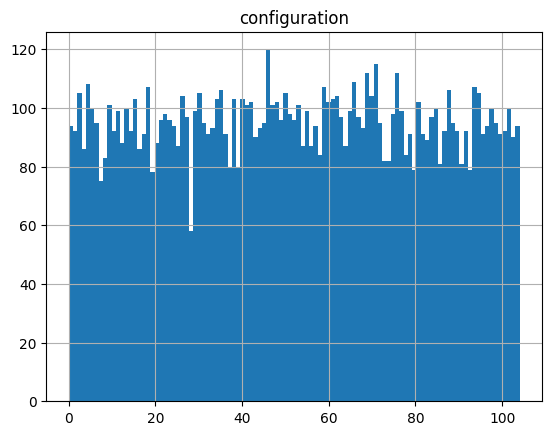

In [9]:
labels_df[['configuration']].hist(bins=105)

In [10]:
config_dist = labels_df["configuration"].value_counts().sort_index()
config_dist.describe()

count    105.000000
mean      95.238095
std        9.364955
min       58.000000
25%       91.000000
50%       95.000000
75%      102.000000
max      120.000000
Name: count, dtype: float64

All of the classes seem to be pretty well represented (except maybe for one, but it still doesn't seem like an issue). Here we've checked for the entire dataset, assuming the train/test split required by the assignment definition was done randomly, the same should hold for the train/test datasets. 

The plotted embeddings are not included in the notebook as they don't really tell any info.
    

## Model setup

In [11]:
import torch

torch.manual_seed(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
from dnn_solver import DataAugmentation
from torch.utils.data import DataLoader

from dnn_solver.types import BrightnessContrastAugmentationConfig, DataAugmentationConfig, FlipAugmentationConfig, GaussianNoiseAugmentationConfig, RandomDeleteAugmentationConfig, RotationAugmentationConfig


config = DataAugmentationConfig(
    flip=FlipAugmentationConfig(probability=0.1, horizontal=True, vertical=True),
    rotation=RotationAugmentationConfig(probability=0.1),
    gaussian_noise=GaussianNoiseAugmentationConfig(probability=0.1, mean=0.0, std=0.05),
    brightness_contrast=BrightnessContrastAugmentationConfig(probability=0.1, brightness=0.1, contrast=0.1),
    random_delete=RandomDeleteAugmentationConfig(probability=0, scale=(0.02, 0.1), ratio=(0.3, 3.3))
)

train_dataset = IMGDataset(train=True, transform=DataAugmentation(config))
val_dataset   = IMGDataset(train=False)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1000, shuffle=False)


In [13]:
from dnn_solver.net import GSNMultiTaskNet
from dnn_solver.trainer import MultiTaskTrainer

# we assume that values are in 2..8, instead of 1..9 as in the original assignment statement, change to 1..9 if needed
VALUES_MIN = 2
VALUES_MAX = 8

def run_experiment(lambda_cnt: float, use_cls_loss: bool, *, epochs: int = 100, weight_decay: float = 1e-4, log_freq: int = 50, patience: int = 15, save_dir: str | None = None):
    use_cls_loss = use_cls_loss
    model = GSNMultiTaskNet(num_classes=15 * (VALUES_MAX - VALUES_MIN + 1), dropout_p=0.3).to(device)
    trainer = MultiTaskTrainer(
        model=model,
        trainloader=train_loader,
        testloader=val_loader,
        device=device,
        lambda_cnt=lambda_cnt,
        use_cls_loss=use_cls_loss,
        values_min=VALUES_MIN,  
        values_max=VALUES_MAX,
    )
    metrics = trainer.train(
        epochs=epochs,
        lr=1e-3,
        weight_decay=weight_decay,
        log_freq=log_freq,
        patience=patience,
    )
    trainer.plot_learning_curves(save_dir=save_dir)
    return metrics


epoch    1, batch    50, loss 4.659
epoch    1, batch   100, loss 4.655
epoch    1 evaluation: loss_total=4.6545, accuracy=0.0070
               loss_cls=4.6545, loss_reg=1.5002
epoch    2, batch    50, loss 4.653
epoch    2, batch   100, loss 4.641
epoch    2 evaluation: loss_total=4.4343, accuracy=0.0210
               loss_cls=4.4343, loss_reg=1.5000
epoch    3, batch    50, loss 4.340
epoch    3, batch   100, loss 4.238
epoch    3 evaluation: loss_total=4.1064, accuracy=0.0320
               loss_cls=4.1064, loss_reg=1.5000
epoch    4, batch    50, loss 4.123
epoch    4, batch   100, loss 4.032
epoch    4 evaluation: loss_total=3.9483, accuracy=0.0420
               loss_cls=3.9483, loss_reg=1.5000
epoch    5, batch    50, loss 3.865

epoch    1, batch    50, loss 4.660
epoch    1, batch   100, loss 4.655
epoch    1 evaluation: loss_total=4.6536, accuracy=0.0070
               loss_cls=4.6536, loss_reg=1.4999
epoch    2, batch    50, loss 4.653
epoch    2, batch   100, loss 4.654
epoch    2 evaluation: loss_total=4.6539, accuracy=0.0120
               loss_cls=4.6539, loss_reg=1.5000
epoch    3, batch    50, loss 4.653
epoch    3, batch   100, loss 4.653
epoch    3 evaluation: loss_total=4.6554, accuracy=0.0100
               loss_cls=4.6554, loss_reg=1.5000
epoch    4, batch    50, loss 4.653
epoch    4, batch   100, loss 4.654
epoch    4 evaluation: loss_total=4.6553, accuracy=0.0090
               loss_cls=4.6553, loss_reg=1.5000
epoch    5, batch    50, loss 4.653
epoch    5, batch   100, loss 4.652
epoch    5 evaluation: loss_total=4.6557, accuracy=0.0140
               loss_cls=4.6557, loss_reg=1.5000
epoch    6, batch    50, loss 4.654
epoch    6, batch   100, loss 4.653
epoch    6 evaluation: loss_total=4.65

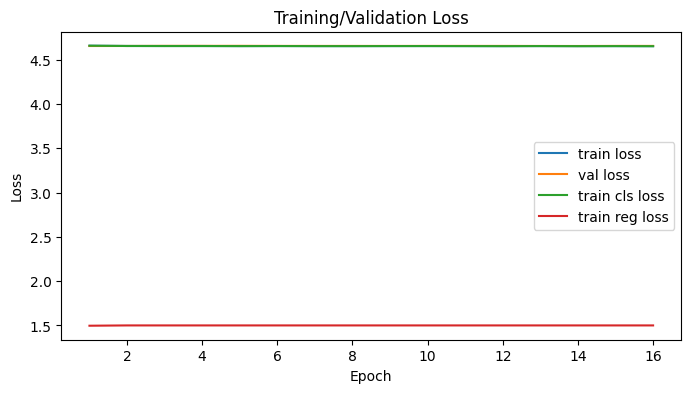

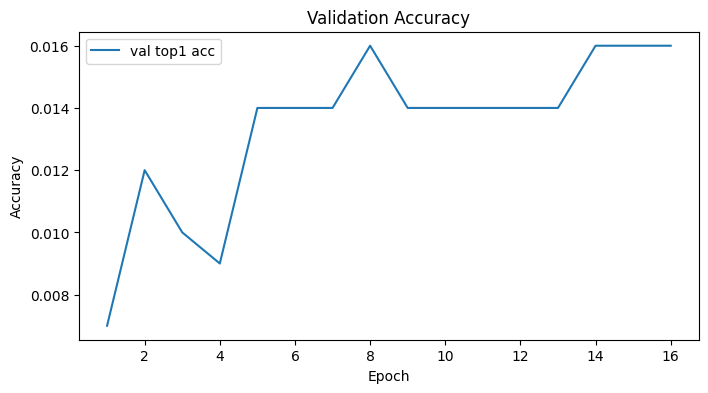

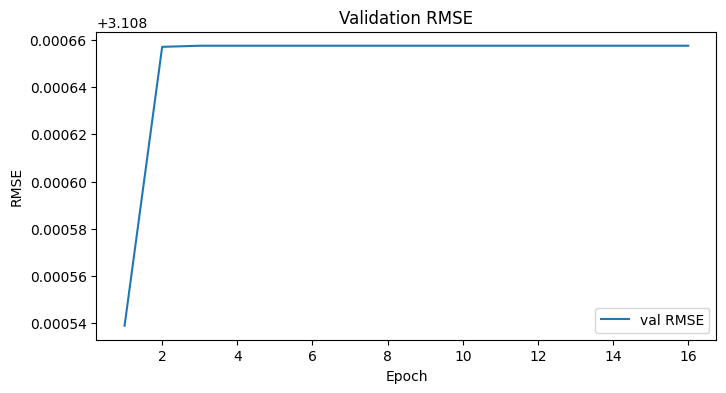

[Loss] loss_total=4.6536, loss_cls=4.6536, loss_reg=1.4999; [Classification] top1=0.0070, macro_f1=0.0001, worst_pairs={'squares+circles': 0.0, 'squares+up': 0.0, 'squares+right': 0.0, 'squares+down': 0.0, 'squares+left': 0.0}; [Regression] rmse_overall=3.1085, mae_overall=1.6667, rmse_per_dim={'squares': 3.0966, 'circles': 3.0976, 'up': 3.1672, 'right': 3.1826, 'down': 3.067, 'left': 3.0403}, mae_per_dim={'squares': 1.651, 'circles': 1.659, 'up': 1.719, 'right': 1.701, 'down': 1.6313, 'left': 1.6391}

In [14]:
run_experiment(lambda_cnt=0, use_cls_loss=True)

epoch    1, batch    50, loss 1.423
epoch    1, batch   100, loss 1.397
epoch    1 evaluation: loss_total=1.1581, accuracy=0.0060
               loss_cls=0.0000, loss_reg=1.1581
epoch    2, batch    50, loss 1.091
epoch    2, batch   100, loss 0.924
epoch    2 evaluation: loss_total=0.7198, accuracy=0.0080
               loss_cls=0.0000, loss_reg=0.7198
epoch    3, batch    50, loss 0.733
epoch    3, batch   100, loss 0.651
epoch    3 evaluation: loss_total=0.5323, accuracy=0.0080
               loss_cls=0.0000, loss_reg=0.5323
epoch    4, batch    50, loss 0.541
epoch    4, batch   100, loss 0.511
epoch    4 evaluation: loss_total=0.4035, accuracy=0.0140
               loss_cls=0.0000, loss_reg=0.4035
epoch    5, batch    50, loss 0.434
epoch    5, batch   100, loss 0.396
epoch    5 evaluation: loss_total=0.3235, accuracy=0.0070
               loss_cls=0.0000, loss_reg=0.3235
epoch    6, batch    50, loss 0.352
epoch    6, batch   100, loss 0.333
epoch    6 evaluation: loss_total=0.31

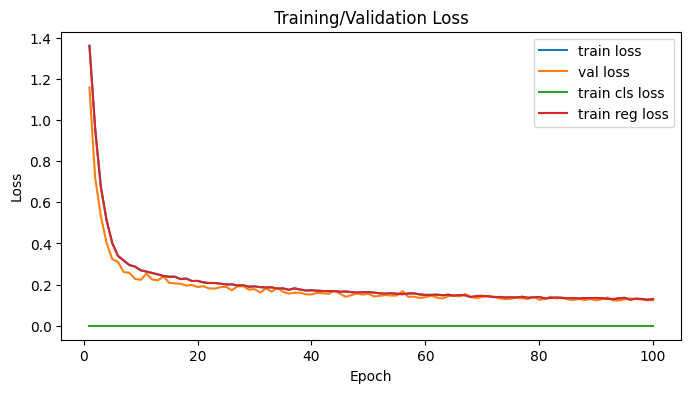

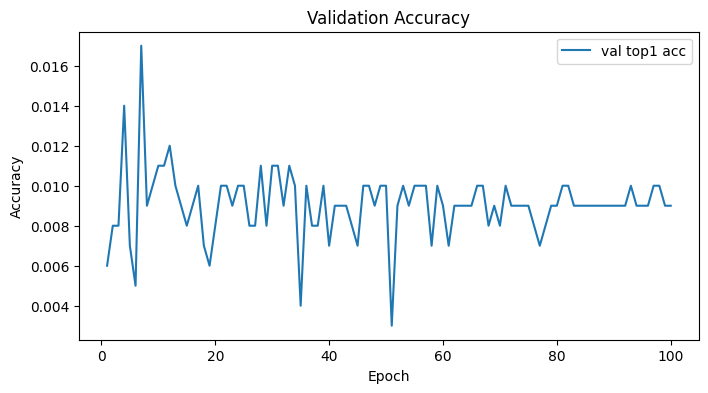

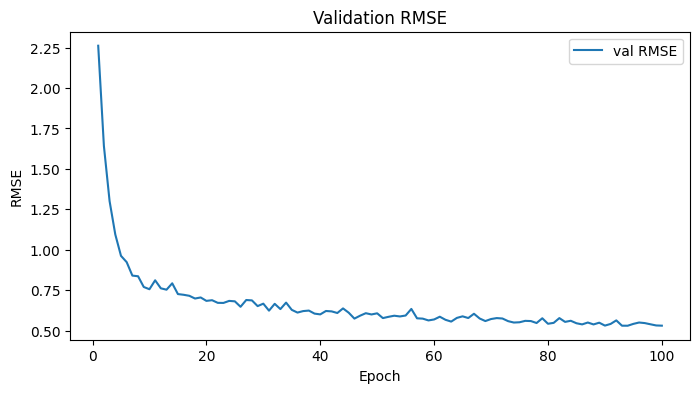

[Loss] loss_total=0.1224, loss_cls=0.0000, loss_reg=0.1224; [Classification] top1=0.0100, macro_f1=0.0002, worst_pairs={'squares+circles': 0.0, 'squares+up': 0.0, 'squares+right': 0.0, 'squares+down': 0.0, 'squares+left': 0.0}; [Regression] rmse_overall=0.5313, mae_overall=0.2909, rmse_per_dim={'squares': 0.4604, 'circles': 0.4759, 'up': 0.5546, 'right': 0.5705, 'down': 0.5332, 'left': 0.5933}, mae_per_dim={'squares': 0.2583, 'circles': 0.2782, 'up': 0.3073, 'right': 0.2956, 'down': 0.2826, 'left': 0.3233}

In [15]:
run_experiment(lambda_cnt=1.0, use_cls_loss=False)

epoch    1, batch    50, loss 6.091
epoch    1, batch   100, loss 6.077
epoch    1 evaluation: loss_total=6.0738, accuracy=0.0160
               loss_cls=4.6561, loss_reg=1.4177
epoch    2, batch    50, loss 6.073
epoch    2, batch   100, loss 6.072
epoch    2 evaluation: loss_total=5.8213, accuracy=0.0300
               loss_cls=4.4916, loss_reg=1.3297
epoch    3, batch    50, loss 5.562
epoch    3, batch   100, loss 5.374
epoch    3 evaluation: loss_total=5.0822, accuracy=0.0360
               loss_cls=3.8477, loss_reg=1.2346
epoch    4, batch    50, loss 5.210
epoch    4, batch   100, loss 5.059
epoch    4 evaluation: loss_total=4.6072, accuracy=0.0610
               loss_cls=3.5711, loss_reg=1.0361
epoch    5, batch    50, loss 4.582
epoch    5, batch   100, loss 4.001
epoch    5 evaluation: loss_total=3.2343, accuracy=0.1790
               loss_cls=2.5867, loss_reg=0.6477
epoch    6, batch    50, loss 3.433
epoch    6, batch   100, loss 3.244
epoch    6 evaluation: loss_total=3.02

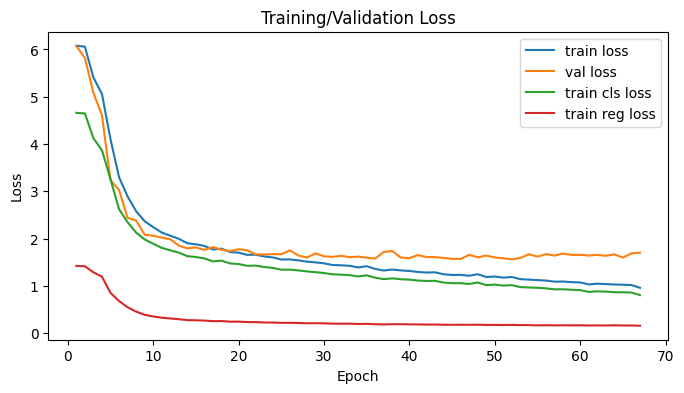

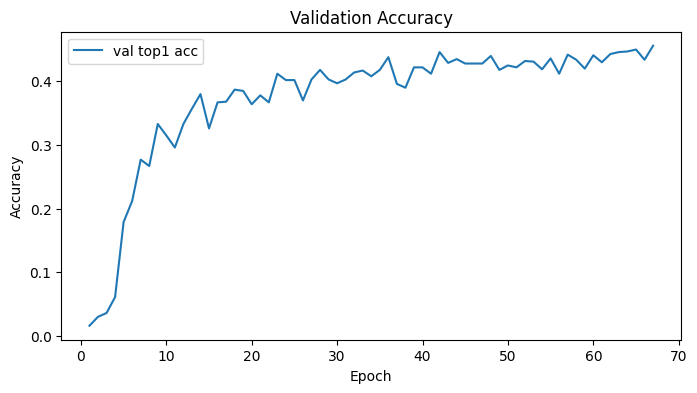

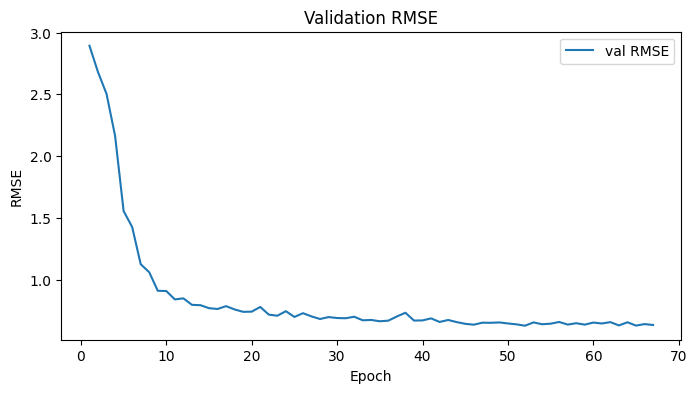

[Loss] loss_total=1.5587, loss_cls=1.3926, loss_reg=0.1662; [Classification] top1=0.4320, macro_f1=0.4079, worst_pairs={'squares+circles': 0.8571, 'right+down': 0.8871, 'squares+right': 0.8889, 'up+left': 0.9077, 'circles+down': 0.918}; [Regression] rmse_overall=0.6291, mae_overall=0.3546, rmse_per_dim={'squares': 0.5564, 'circles': 0.5532, 'up': 0.6604, 'right': 0.6738, 'down': 0.6899, 'left': 0.6411}, mae_per_dim={'squares': 0.3255, 'circles': 0.3224, 'up': 0.3864, 'right': 0.3625, 'down': 0.3704, 'left': 0.3602}

In [16]:
run_experiment(lambda_cnt=1.0, use_cls_loss=True)